
=== Classification Report ===
              precision    recall  f1-score   support

         MCI       0.71      0.83      0.77         6
      Normal       0.67      0.50      0.57         4

    accuracy                           0.70        10
   macro avg       0.69      0.67      0.67        10
weighted avg       0.70      0.70      0.69        10


Accuracy: 0.7


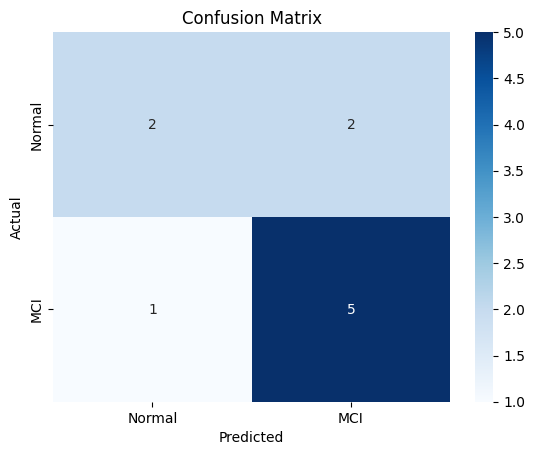

Cross-val accuracy: 0.562


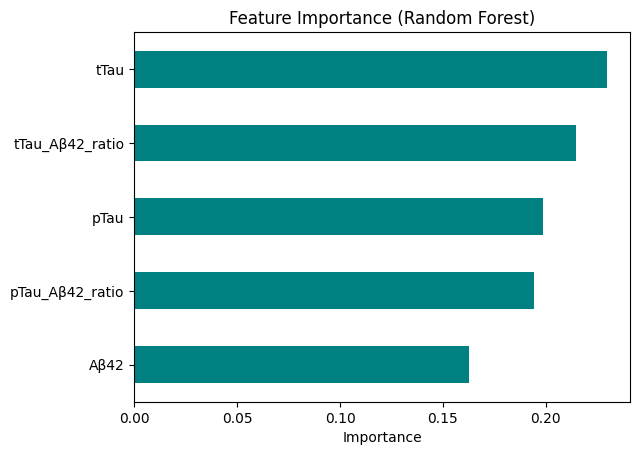

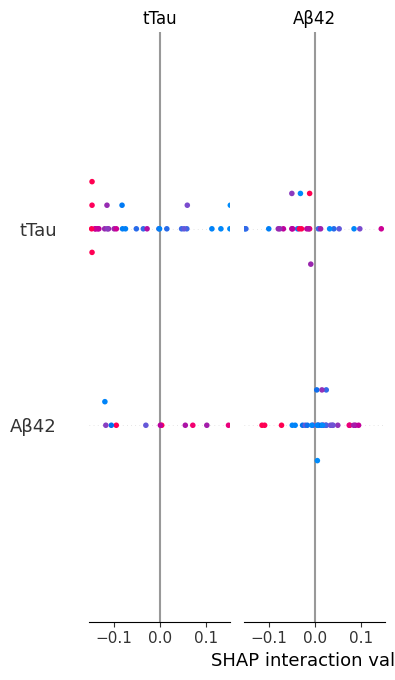

In [ ]:
# ===========================================
# ✅ Fixed Version: Random Forest for CDR
# ===========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import shap

# 1️⃣ Load and preprocess
df = pd.read_csv("/content/data-2025-10-17T18_58_50.423Z.csv")

df = df.rename(columns={
    'Clinical_Assessment Clinical_Biomarker_CSF_Analysis_Data,000_amyloid_1_42': 'Aβ42',
    'Clinical_Assessment Clinical_Biomarker_CSF_Analysis_Data,002_Tau': 'tTau',
    'Clinical_Assessment Clinical_Biomarker_CSF_Analysis_Data,004_pTAU': 'pTau',
    'Initial_Assessment_Screening Screening_Clinical_Dementia_Rating,013_global_CDR': 'CDR'
})

cols = ['Aβ42', 'tTau', 'pTau', 'CDR']
df = df[cols]

for c in cols:
    df[c] = pd.to_numeric(df[c].replace('.', np.nan), errors='coerce')

df = df.dropna()

# Derived ratios
df['pTau_Aβ42_ratio'] = df['pTau'] / df['Aβ42']
df['tTau_Aβ42_ratio'] = df['tTau'] / df['Aβ42']

# 2️⃣ Convert continuous labels to categorical
df['CDR_label'] = df['CDR'].apply(lambda x: 'Normal' if x == 0 else 'MCI')

X = df[['Aβ42', 'tTau', 'pTau', 'pTau_Aβ42_ratio', 'tTau_Aβ42_ratio']]
y = df['CDR_label']

# 3️⃣ Split & Train
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight="balanced",
    random_state=42
)
rf.fit(X_train, y_train)

# 4️⃣ Evaluate
y_pred = rf.predict(X_test)
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))
print("\nAccuracy:", round(accuracy_score(y_test, y_pred), 3))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=['Normal', 'MCI'])
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d', xticklabels=['Normal','MCI'], yticklabels=['Normal','MCI'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Cross-validation
cv_score = cross_val_score(rf, X, y, cv=5, scoring='accuracy')
print("Cross-val accuracy:", round(cv_score.mean(), 3))

# 5️⃣ Feature Importance
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)
feat_imp.plot(kind="barh", color="teal")
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.show()

# 6️⃣ SHAP Summary (optional)
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X)
shap.summary_plot(shap_values, X, plot_type="bar", show=True)


Original samples: 31, After augmentation: 186

=== Classification Report ===
              precision    recall  f1-score   support

         MCI       0.89      0.97      0.93        33
      Normal       0.95      0.83      0.88        23

    accuracy                           0.91        56
   macro avg       0.92      0.90      0.91        56
weighted avg       0.91      0.91      0.91        56

Accuracy: 0.911


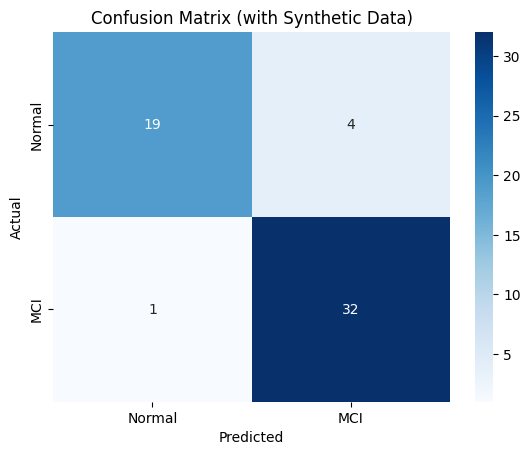

Cross-val accuracy: 0.865


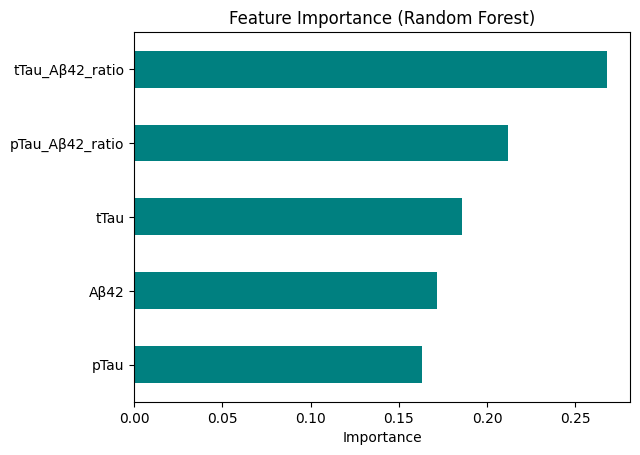

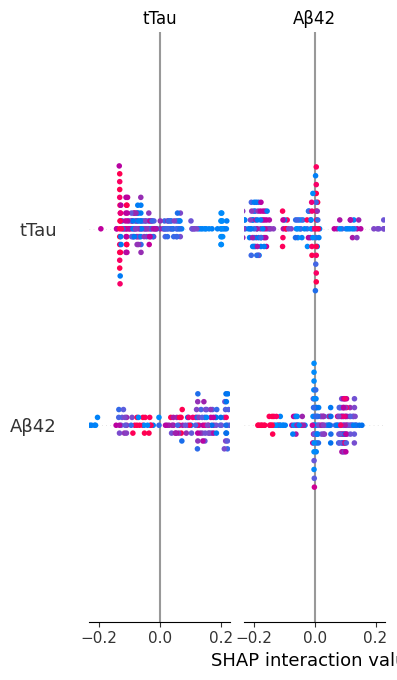

✅ Saved full CCNA model results as ccna_results.pkl


In [ ]:
# ===========================================
# 🧠 Random Forest + SHAP with Synthetic Data (Gaussian Augmentation)
# ===========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import shap

# 1️⃣ Load and preprocess
df = pd.read_csv("data-2025-10-17T18_58_50.423Z.csv")

df = df.rename(columns={
    'Clinical_Assessment Clinical_Biomarker_CSF_Analysis_Data,000_amyloid_1_42': 'Aβ42',
    'Clinical_Assessment Clinical_Biomarker_CSF_Analysis_Data,002_Tau': 'tTau',
    'Clinical_Assessment Clinical_Biomarker_CSF_Analysis_Data,004_pTAU': 'pTau',
    'Initial_Assessment_Screening Screening_Clinical_Dementia_Rating,013_global_CDR': 'CDR'
})

cols = ['Aβ42', 'tTau', 'pTau', 'CDR']
df = df[cols]

for c in cols:
    df[c] = pd.to_numeric(df[c].replace('.', np.nan), errors='coerce')

df = df.dropna()

# Derived ratios
df['pTau_Aβ42_ratio'] = df['pTau'] / df['Aβ42']
df['tTau_Aβ42_ratio'] = df['tTau'] / df['Aβ42']

# 2️⃣ Convert continuous labels to categorical (binary)
df['CDR_label'] = df['CDR'].apply(lambda x: 'Normal' if x == 0 else 'MCI')

X = df[['Aβ42', 'tTau', 'pTau', 'pTau_Aβ42_ratio', 'tTau_Aβ42_ratio']]
y = df['CDR_label']

# ===========================================
# 🔬 Synthetic Gaussian Augmentation
# ===========================================
def augment_data(X, y, n_factor=5, noise_std=0.05):
    X_aug = []
    y_aug = []
    for i in range(len(X)):
        for _ in range(n_factor):
            noise = np.random.normal(0, noise_std, X.shape[1])
            X_aug.append(X.iloc[i] * (1 + noise))
            y_aug.append(y.iloc[i])
    X_aug = pd.DataFrame(X_aug, columns=X.columns)
    y_aug = pd.Series(y_aug)
    return pd.concat([X, X_aug], ignore_index=True), pd.concat([y, y_aug], ignore_index=True)

# Generate 5× more samples
X_aug, y_aug = augment_data(X, y, n_factor=5, noise_std=0.05)

print(f"Original samples: {len(X)}, After augmentation: {len(X_aug)}")

# 3️⃣ Split & Train
X_train, X_test, y_train, y_test = train_test_split(
    X_aug, y_aug, test_size=0.3, random_state=42, stratify=y_aug
)

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight="balanced",
    random_state=42
)
rf.fit(X_train, y_train)

# 4️⃣ Evaluate
y_pred = rf.predict(X_test)
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))
print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=['Normal', 'MCI'])
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d',
            xticklabels=['Normal','MCI'], yticklabels=['Normal','MCI'])
plt.title("Confusion Matrix (with Synthetic Data)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Cross-validation
cv_score = cross_val_score(rf, X_aug, y_aug, cv=5, scoring='accuracy')
print("Cross-val accuracy:", round(cv_score.mean(), 3))

# 5️⃣ Feature Importance
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)
feat_imp.plot(kind="barh", color="teal")
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.show()

# 6️⃣ SHAP Summary
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_aug)
shap.summary_plot(shap_values, X_aug, plot_type="bar", show=True)
# ============================================================
# 7️⃣ Save model, predictions, and SHAP results as .pkl
# ============================================================
import pickle

# Get probabilities (for “MCI” class)
p_pred = rf.predict_proba(X_test)[:, 1]

# Mean absolute SHAP values for feature importance
try:
    feature_names = X.columns
except AttributeError:
    feature_names = [f"Feature_{i}" for i in range(X.shape[1])]

# Handle SHAP output (multi-class safety)
if isinstance(shap_values, list):
    shap_mean = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
else:
    shap_mean = np.abs(shap_values).mean(axis=0)

shap_importance = dict(zip(feature_names, shap_mean))

# Save everything you need
results = {
    "model": rf,
    "y_pred": y_pred,
    "p_pred": p_pred,
    "cm": cm,
    "shap_importance": shap_importance
}

# Change filename depending on dataset
with open("ccna_results.pkl", "wb") as f:
    pickle.dump(results, f)

print("✅ Saved full CCNA model results as ccna_results.pkl")


Before SMOTE: {'Normal': 396, 'MCI': 364, 'MildAD': 8}
After SMOTE: {'Normal': 396, 'MCI': 396, 'MildAD': 396}

=== Classification Report ===
              precision    recall  f1-score   support

         MCI       0.67      0.03      0.05        79
      MildAD       0.34      1.00      0.50        79
      Normal       0.00      0.00      0.00        80

    accuracy                           0.34       238
   macro avg       0.33      0.34      0.18       238
weighted avg       0.33      0.34      0.18       238


Accuracy: 0.34


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


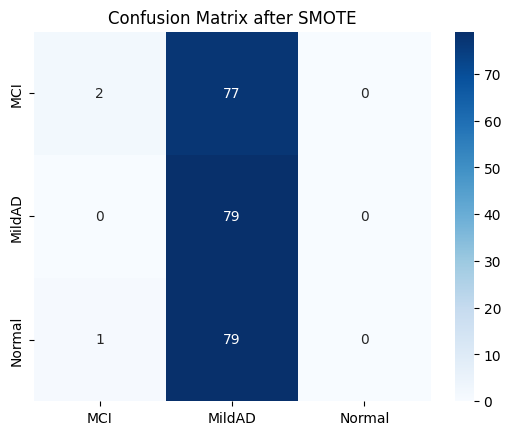

In [ ]:
# ===========================================
# 💥 Random Forest with Imputation + SMOTE
# ===========================================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt

# 1️⃣ Load data
df = pd.read_csv("data-2025-10-17T18_58_50.423Z.csv")

df = df.rename(columns={
    'Clinical_Assessment Clinical_Biomarker_CSF_Analysis_Data,000_amyloid_1_42': 'Aβ42',
    'Clinical_Assessment Clinical_Biomarker_CSF_Analysis_Data,002_Tau': 'tTau',
    'Clinical_Assessment Clinical_Biomarker_CSF_Analysis_Data,004_pTAU': 'pTau',
    'Initial_Assessment_Screening Screening_Clinical_Dementia_Rating,013_global_CDR': 'CDR'
})

cols = ['Aβ42', 'tTau', 'pTau', 'CDR']
df = df[cols].replace('.', np.nan)

for c in cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

# 2️⃣ Impute missing biomarker values
imputer = IterativeImputer(random_state=42)
biomarkers = ['Aβ42', 'tTau', 'pTau']
df[biomarkers] = imputer.fit_transform(df[biomarkers])

# Derived ratios
df['pTau_Aβ42_ratio'] = df['pTau'] / df['Aβ42']
df['tTau_Aβ42_ratio'] = df['tTau'] / df['Aβ42']

# Drop rows with missing CDR
df = df.dropna(subset=['CDR'])

# Convert CDR to categorical label
def cdr_label(x):
    if x == 0:
        return "Normal"
    elif x == 0.5:
        return "MCI"
    elif x == 1:
        return "MildAD"
    else:
        return "SevereAD"

df['CDR_label'] = df['CDR'].apply(cdr_label)

# 3️⃣ Split X and y
X = df[['Aβ42', 'tTau', 'pTau', 'pTau_Aβ42_ratio', 'tTau_Aβ42_ratio']]
y = df['CDR_label']

# 4️⃣ Apply SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

print("Before SMOTE:", y.value_counts().to_dict())
print("After SMOTE:", y_res.value_counts().to_dict())

# 5️⃣ Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42, stratify=y_res)

# 6️⃣ Train Random Forest
rf = RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced")
rf.fit(X_train, y_train)

# 7️⃣ Evaluate
y_pred = rf.predict(X_test)
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))
print("\nAccuracy:", round(accuracy_score(y_test, y_pred), 3))

cm = confusion_matrix(y_test, y_pred, labels=rf.classes_)
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", xticklabels=rf.classes_, yticklabels=rf.classes_)
plt.title("Confusion Matrix after SMOTE")
plt.show()



=== Classification Report ===
              precision    recall  f1-score   support

           0       0.52      0.97      0.68       119
           1       0.62      0.04      0.08       112

    accuracy                           0.52       231
   macro avg       0.57      0.51      0.38       231
weighted avg       0.57      0.52      0.39       231

Accuracy: 0.524


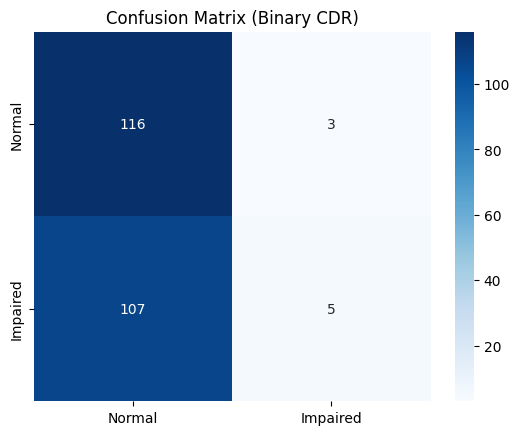

Cross-val Accuracy: 0.518


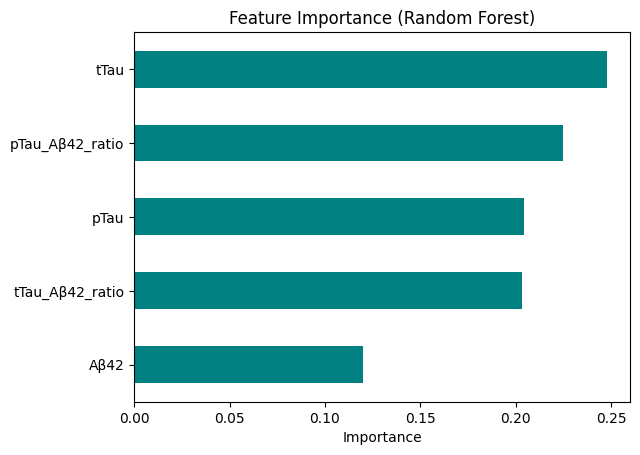

In [ ]:
# ===========================================
# 🧠 CCNA CSF Biomarker Binary Model
# ===========================================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import seaborn as sns
import matplotlib.pyplot as plt

# 1️⃣ Load & clean
df = pd.read_csv("data-2025-10-17T18_58_50.423Z.csv")

df = df.rename(columns={
    'Clinical_Assessment Clinical_Biomarker_CSF_Analysis_Data,000_amyloid_1_42': 'Aβ42',
    'Clinical_Assessment Clinical_Biomarker_CSF_Analysis_Data,002_Tau': 'tTau',
    'Clinical_Assessment Clinical_Biomarker_CSF_Analysis_Data,004_pTAU': 'pTau',
    'Initial_Assessment_Screening Screening_Clinical_Dementia_Rating,013_global_CDR': 'CDR'
})

df = df[['Aβ42', 'tTau', 'pTau', 'CDR']].replace('.', np.nan)
for c in ['Aβ42','tTau','pTau','CDR']:
    df[c] = pd.to_numeric(df[c], errors='coerce')

# Drop rows missing CDR
df = df.dropna(subset=['CDR'])

# 2️⃣ Impute missing biomarker values
imputer = IterativeImputer(random_state=42)
df[['Aβ42','tTau','pTau']] = imputer.fit_transform(df[['Aβ42','tTau','pTau']])

# Derived ratios
df['pTau_Aβ42_ratio'] = df['pTau'] / df['Aβ42']
df['tTau_Aβ42_ratio'] = df['tTau'] / df['Aβ42']

# 3️⃣ Binary label: Normal (0) vs Impaired (≥0.5)
df['CDR_binary'] = (df['CDR'] >= 0.5).astype(int)

X = df[['Aβ42','tTau','pTau','pTau_Aβ42_ratio','tTau_Aβ42_ratio']]
y = df['CDR_binary']

# 4️⃣ Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# 5️⃣ Random Forest model
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=8,
    min_samples_leaf=3,
    random_state=42
)
rf.fit(X_train, y_train)

# 6️⃣ Evaluation
y_pred = rf.predict(X_test)
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))
print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", xticklabels=["Normal","Impaired"], yticklabels=["Normal","Impaired"])
plt.title("Confusion Matrix (Binary CDR)")
plt.show()

# Cross-validation
cv = cross_val_score(rf, X, y, cv=5, scoring='accuracy')
print("Cross-val Accuracy:", round(cv.mean(), 3))

# 7️⃣ Feature importance
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
feat_imp.plot(kind="barh", color="teal")
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.show()


In [ ]:
# ============================================================
# 7️⃣ Save model, predictions, and SHAP results as .pkl
# ============================================================
import pickle

# Get probabilities (for “MCI” class)
p_pred = rf.predict_proba(X_test)[:, 1]

# Mean absolute SHAP values for feature importance
try:
    feature_names = X.columns
except AttributeError:
    feature_names = [f"Feature_{i}" for i in range(X.shape[1])]

# Handle SHAP output (multi-class safety)
if isinstance(shap_values, list):
    shap_mean = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
else:
    shap_mean = np.abs(shap_values).mean(axis=0)

shap_importance = dict(zip(feature_names, shap_mean))

# Save everything you need
results = {
    "model": rf,
    "y_pred": y_pred,
    "p_pred": p_pred,
    "cm": cm,
    "shap_importance": shap_importance
}

# Change filename depending on dataset
with open("ccna_results.pkl", "wb") as f:
    pickle.dump(results, f)

print("✅ Saved full CCNA model results as ccna_results.pkl")


NameError: name 'rf' is not defined